In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib


2025-09-20 05:29:39.279357: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-20 05:29:39.335403: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-20 05:29:40.206508: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
EVAL_ONLY = True
# 加载预训练模型
model_path = 'TCNmodel/lstm_tcn_model.h5'
pretrained_model = load_model(model_path)


# 冻结更少的层（例如，只冻结前两层）
for layer in pretrained_model.layers[:1]:  
    layer.trainable = False

# 添加新的输出层（根据新任务的需求）
x = pretrained_model.layers[-2].output
new_output = Dense(1, activation='linear')(x)  # 假设是回归任务

# 创建新的模型
new_model = Model(inputs=pretrained_model.input, outputs=new_output)

# 编译新模型
new_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

2025-09-20 05:29:43.062417: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9613 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:b4:00.0, compute capability: 7.5


In [3]:
# 加载新数据
new_data = pd.read_csv("Fill-1.csv")  # 确保文件名正确

# 检查并处理 NaN 值
if new_data.isnull().values.any():
    print("新数据中存在 NaN 值，正在处理...")
    new_data = new_data.dropna()  # 删除包含 NaN 的行
    # 或者使用 new_data.fillna(new_data.mean(), inplace=True) 填充 NaN

new_inputs = new_data.iloc[:, :2].values
new_output = new_data.iloc[:, 2].values.reshape(-1, 1)

# 加载保存的scaler
scaler_in = joblib.load('scalers/scaler_in.pkl')
scaler_out = joblib.load('scalers/scaler_out.pkl')

# 使用加载的scaler进行归一化
new_inputs = scaler_in.transform(new_inputs)
new_output = scaler_out.transform(new_output)

# 重新调整输入形状
timesteps = 1
new_inputs = new_inputs.reshape((new_inputs.shape[0], timesteps, new_inputs.shape[1]))


In [ ]:
# 训练新模型
history = new_model.fit(new_inputs, new_output, epochs=10, batch_size=200, validation_split=0.2)



In [4]:
model = load_model("TCNmodel/lstm_tcn_tl_model_finetuned.h5")

In [5]:
from tensorflow.keras.models import load_model
# 明确指定迁移学习后模型的保存路径

tl_model_path = 'TCNmodel/lstm_tcn_tl_model_finetuned.h5'
new_model = load_model(tl_model_path, compile=False)
# 评估新模型
new_predictions = new_model.predict(new_inputs).flatten()
new_output = new_output.flatten()

# 计算指标
new_rmse = np.sqrt(mean_squared_error(new_output, new_predictions))
new_mae = mean_absolute_error(new_output, new_predictions)
new_r2 = r2_score(new_output, new_predictions)

print(f"New RMSE: {new_rmse}, New MAE: {new_mae}, New R²: {new_r2}")


2025-09-20 05:30:01.200544: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600


5299/5299 [==============================] - 15s 2ms/step
New RMSE: 0.09737815709528701, New MAE: 0.0396415647706818, New R²: 0.7925443860096666


In [103]:
# 保存迁移学习后的模型
new_model_path = 'TCNmodel/lstm_tcn_tl_model_finetuned.h5'
new_model.save(new_model_path)
print(f"Fine-tuned model saved to {new_model_path}")


Fine-tuned model saved to TCNmodel/lstm_tcn_tl_model_finetuned.h5


/root/miniconda3/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


损失图已保存到: lstmtcn_tl_fig/lstm_loss_plot.png
局部放大损失图已保存到: lstmtcn_tl_fig/zoom_loss_plot.png


/tmp/ipykernel_98341/748199914.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


结合图已保存到: lstmtcn_tl_fig/combined_plot_zoomed.png


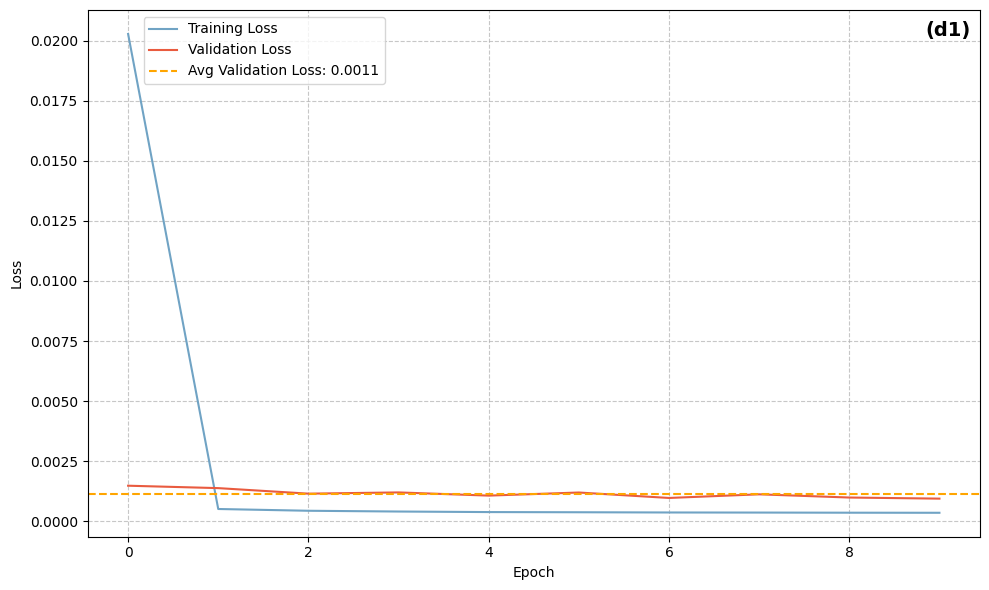

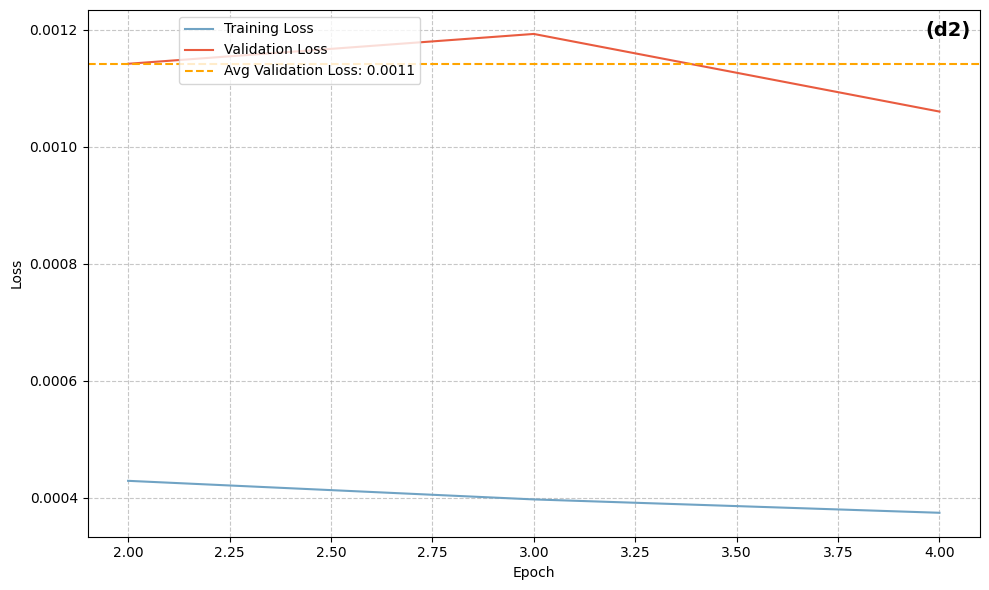

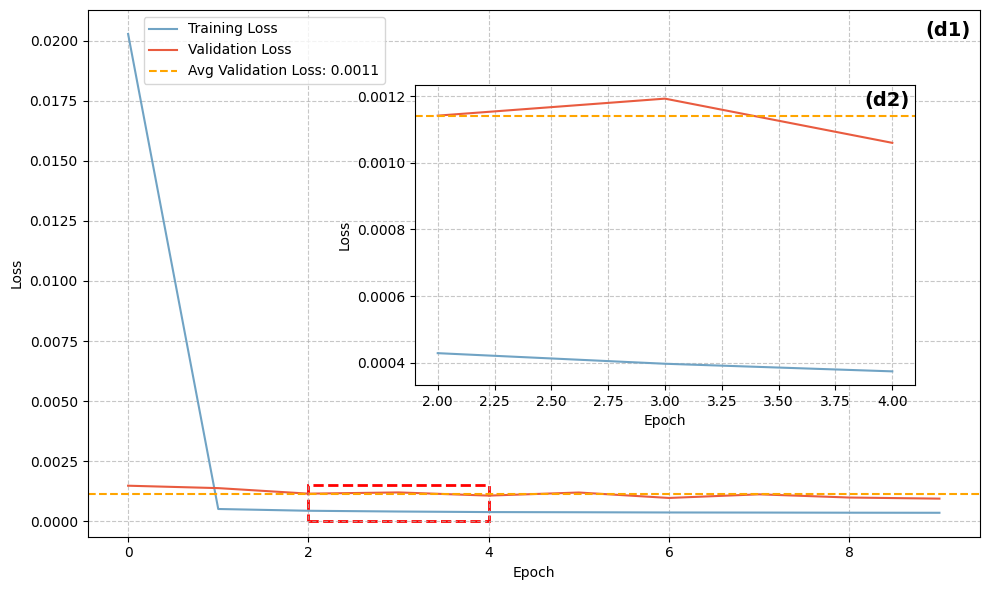

In [104]:
# 创建文件夹保存图像
folder_name = "lstmtcn_tl_fig"
os.makedirs(folder_name, exist_ok=True)

train_loss = history.history['loss']
val_loss = history.history['val_loss']
avg_val_loss = np.mean(val_loss)

# 绘制损失曲线
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(train_loss, color='#70A3C4', label='Training Loss')
ax1.plot(val_loss, color='#E95B3F', label='Validation Loss')
ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.text(0.99, 0.98, '(d1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
plt.tight_layout()
loss_file_path = os.path.join(folder_name, 'lstm_loss_plot.png')
plt.savefig(loss_file_path, dpi=300, bbox_inches='tight')
print(f"损失图已保存到: {loss_file_path}")

# 手动定义红框区域
red_box_start = 2
red_box_end = 4
red_box_y_min =0
red_box_y_max = 0.0015

# 手动定义放大区域
zoom_epoch_start = 2
zoom_epoch_end = 5

# 绘制局部放大损失曲线
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(range(zoom_epoch_start, zoom_epoch_end), train_loss[zoom_epoch_start:zoom_epoch_end], color='#70A3C4', label='Training Loss')
ax2.plot(range(zoom_epoch_start, zoom_epoch_end), val_loss[zoom_epoch_start:zoom_epoch_end], color='#E95B3F', label='Validation Loss')
ax2.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax2.legend(loc='upper left', bbox_to_anchor=(0.095, 1), bbox_transform=ax2.transAxes)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.text(0.99, 0.98, '(d2)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
plt.tight_layout()
zoom_loss_file_path = os.path.join(folder_name, 'zoom_loss_plot.png')
plt.savefig(zoom_loss_file_path, dpi=300, bbox_inches='tight')
print(f"局部放大损失图已保存到: {zoom_loss_file_path}")

# 绘制结合图
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(train_loss, color='#70A3C4', label='Training Loss')
ax1.plot(val_loss, color='#E95B3F', label='Validation Loss')
ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.text(0.99, 0.98, '(d1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# Inset zoomed-in loss
inset_ax = fig.add_axes([0.42, 0.35, 0.5, 0.5])
inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), train_loss[zoom_epoch_start:zoom_epoch_end], color='#70A3C4')
inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), val_loss[zoom_epoch_start:zoom_epoch_end], color='#E95B3F')
inset_ax.axhline(y=avg_val_loss, color='#FFA500', linestyle='--')
inset_ax.set_xlabel('Epoch')
inset_ax.set_ylabel('Loss')
inset_ax.grid(True, linestyle='--', alpha=0.7)
inset_ax.text(0.99, 0.98, '(d2)', transform=inset_ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 添加红色虚线矩形
rect = plt.Rectangle((red_box_start, red_box_y_min),  # 起始位置 (x, y)
                     red_box_end - red_box_start,  # 宽度
                     red_box_y_max - red_box_y_min,  # 高度
                     edgecolor='red', linestyle='--', linewidth=2, facecolor='none', transform=ax1.transData)

ax1.add_patch(rect)

plt.tight_layout()
combined_file_path = os.path.join(folder_name, 'combined_plot_zoomed.png')
plt.savefig(combined_file_path, dpi=300, bbox_inches='tight')
print(f"结合图已保存到: {combined_file_path}")

plt.show()


825/825 [==============================] - 3s 3ms/step


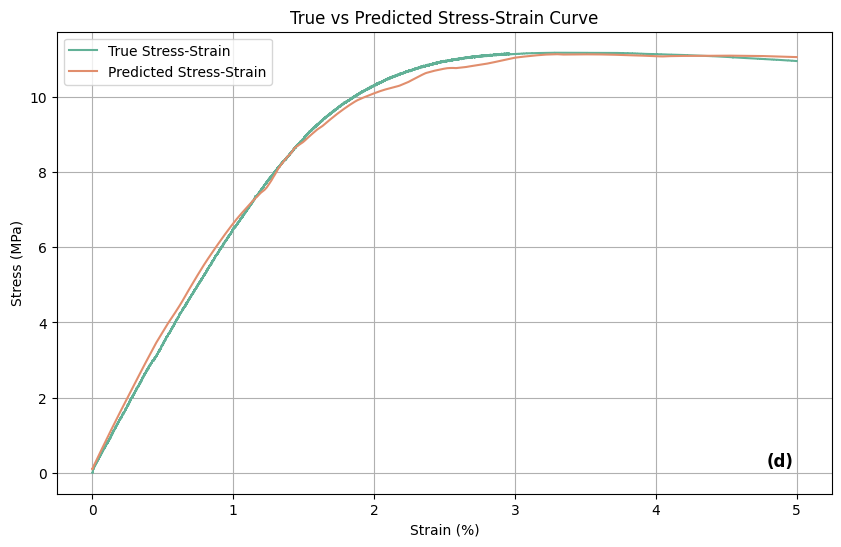

In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib

# 确保保存图片的文件夹存在
folder_path = os.path.join('lstmtcn_tl_fig', 'prediction')
os.makedirs(folder_path, exist_ok=True)

# 加载保存的scaler
scaler_in = joblib.load('scalers/scaler_in.pkl')
scaler_out = joblib.load('scalers/scaler_out.pkl')

# 读取新数据
file_name = '60-p.csv'  # 使用正确的数据集
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值
stress_true = df_new_data.iloc[:, 2].values  # 第三列为真实应力值

# 对新数据进行归一化处理
x_new = df_new_data.iloc[:, :2].values  # 取前两列作为输入特征
x_new_scaled = scaler_in.transform(x_new)

# 创建新数据序列
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data) - sequence_length + 1):
        sequences.append(data[i:i + sequence_length])
    return np.array(sequences)

sequence_length = 1  # 根据之前的模型设置
x_new_seq = create_sequences(x_new_scaled, sequence_length)

# 加载迁移学习后的模型
model_path = os.path.join('TCNmodel', 'lstm_tcn_tl_model_finetuned.h5')
model = load_model(model_path)

# 进行预测
y_pred_scaled = model.predict(x_new_seq)

# 将预测值从三维转换为二维
y_pred_scaled_2d = y_pred_scaled.reshape(-1, y_pred_scaled.shape[-1])

# 将预测值逆归一化，恢复到原始尺度
stress_pred = scaler_out.inverse_transform(y_pred_scaled_2d).flatten()

# 确保预测值和实际值的长度相同
min_length = min(len(strain), len(stress_pred))
strain_truncated = strain[:min_length]
stress_true_truncated = stress_true[:min_length]
stress_pred_truncated = stress_pred[:min_length]

# 过滤应变值小于或等于5的数据
mask = strain_truncated <= 5
strain_filtered = strain_truncated[mask]
stress_true_filtered = stress_true_truncated[mask]
stress_pred_filtered = stress_pred_truncated[mask]

# 绘制预测结果与真实值的对比图
plt.figure(figsize=(10, 6))
plt.plot(strain_filtered, stress_true_filtered, label='True Stress-Strain', color='#62B197')
plt.plot(strain_filtered, stress_pred_filtered, label='Predicted Stress-Strain', color='#E18E6D')
plt.xlabel('Strain (%)')
plt.ylabel('Stress (MPa)')
plt.legend()
plt.title('True vs Predicted Stress-Strain Curve')
plt.grid(True)
# 在右下角添加文本 (d)
plt.text(0.95, 0.05, '(d)', fontsize=12, fontweight='bold', ha='right', va='bottom', transform=plt.gca().transAxes)
# 保存图片
plt.savefig(os.path.join(folder_path, 'predicted_vs_true_stress_strain.png'))
plt.show()

825/825 [==============================] - 3s 3ms/step


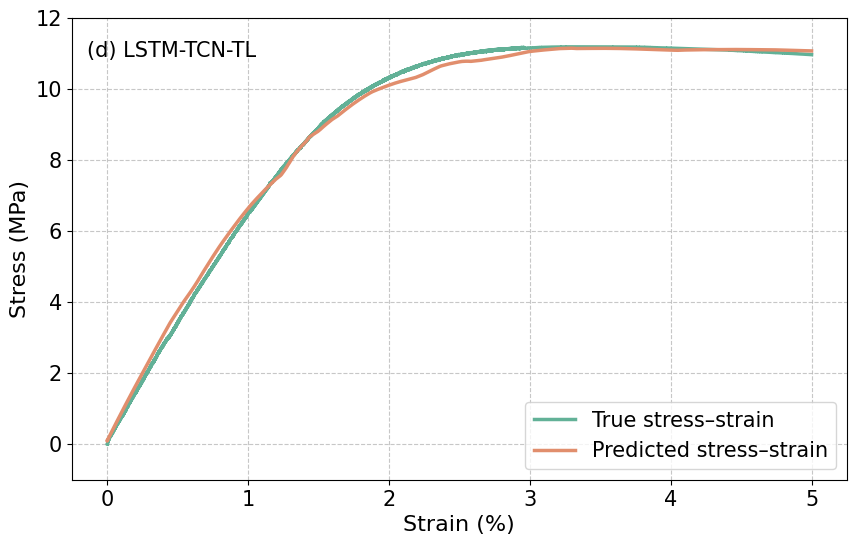

应力-应变曲线已保存并显示: lstmtcn_tl_fig/prediction/predicted_vs_true_stress_strain.png


In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib

# 确保保存图片的文件夹存在
folder_path = os.path.join('lstmtcn_tl_fig', 'prediction')
os.makedirs(folder_path, exist_ok=True)

# 加载保存的scaler
scaler_in = joblib.load('scalers/scaler_in.pkl')
scaler_out = joblib.load('scalers/scaler_out.pkl')

# 读取新数据
file_name = '60-p.csv'  # 使用正确的数据集
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值
stress_true = df_new_data.iloc[:, 2].values  # 第三列为真实应力值

# 对新数据进行归一化处理
x_new = df_new_data.iloc[:, :2].values  # 取前两列作为输入特征
x_new_scaled = scaler_in.transform(x_new)

# 创建新数据序列
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data) - sequence_length + 1):
        sequences.append(data[i:i + sequence_length])
    return np.array(sequences)

sequence_length = 1  # 根据之前的模型设置
x_new_seq = create_sequences(x_new_scaled, sequence_length)

# 加载迁移学习后的模型
model_path = os.path.join('TCNmodel', 'lstm_tcn_tl_model_finetuned.h5')
model = load_model(model_path)

# 进行预测
y_pred_scaled = model.predict(x_new_seq)

# 将预测值从三维转换为二维
y_pred_scaled_2d = y_pred_scaled.reshape(-1, y_pred_scaled.shape[-1])

# 将预测值逆归一化，恢复到原始尺度
stress_pred = scaler_out.inverse_transform(y_pred_scaled_2d).flatten()

# 确保预测值和实际值的长度相同
min_length = min(len(strain), len(stress_pred))
strain_truncated = strain[:min_length]
stress_true_truncated = stress_true[:min_length]
stress_pred_truncated = stress_pred[:min_length]

# 过滤应变值小于或等于5的数据（保持不变）
mask = strain_truncated <= 5
strain_filtered = strain_truncated[mask]
stress_true_filtered = stress_true_truncated[mask]
stress_pred_filtered = stress_pred_truncated[mask]

# TL 标准：预测曲线 < 0 的部分不显示
stress_pred_display = stress_pred_filtered.copy()
stress_pred_display[stress_pred_display < 0] = np.nan

# —— 绘图（TL 统一样式） ——
plt.figure(figsize=(10, 6))
plt.plot(strain_filtered, stress_true_filtered,
         label='True stress–strain', color='#62B197', linewidth=2.5)
plt.plot(strain_filtered, stress_pred_display,
         label='Predicted stress–strain', color='#E18E6D', linewidth=2.5)

# 坐标轴与刻度字号
plt.xlabel('Strain (%)', fontsize=16)
plt.ylabel('Stress (MPa)', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# 固定 y 轴范围（与 TL 图一致）
plt.ylim(-1, 12)

# 图例与网格
plt.legend(fontsize=15, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# 左上角角标（模型名 + 面板序号）
plt.text(0.02, 0.95, '(d) LSTM-TCN-TL', transform=plt.gca().transAxes,
         fontsize=15, ha='left', va='top')

# 保存图片（高清）
save_path = os.path.join(folder_path, 'predicted_vs_true_stress_strain.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# 显示并关闭
plt.show()
plt.close()

print(f"应力-应变曲线已保存并显示: {save_path}")


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib

# 确保保存图片的文件夹存在
folder_path = os.path.join('lstmtcn_tl_fig', 'prediction')
os.makedirs(folder_path, exist_ok=True)

# 加载保存的scaler
scaler_in = joblib.load('scalers/scaler_in.pkl')
scaler_out = joblib.load('scalers/scaler_out.pkl')

# 读取新数据
file_name = '60-p.csv'  # 使用正确的数据集
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值
stress_true = df_new_data.iloc[:, 2].values  # 第三列为真实应力值

# 对新数据进行归一化处理
x_new = df_new_data.iloc[:, :2].values  # 取前两列作为输入特征
x_new_scaled = scaler_in.transform(x_new)

# 创建新数据序列
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

sequence_length = 1  # 根据之前的模型设置
x_new_seq = create_sequences(x_new_scaled, sequence_length)

# 加载迁移学习后的模型
model_path = os.path.join('TCNmodel', 'lstm_tcn_tl_model_finetuned.h5')
model = load_model(model_path)

# 进行预测
y_pred_scaled = model.predict(x_new_seq)

# 将预测值从三维转换为二维
y_pred_scaled_2d = y_pred_scaled.reshape(-1, y_pred_scaled.shape[-1])

# 将预测值逆归一化，恢复到原始尺度
stress_pred = scaler_out.inverse_transform(y_pred_scaled_2d).flatten()

# 确保预测值和实际值的长度相同
min_length = min(len(strain), len(stress_pred))
strain_truncated = strain[:min_length]
stress_true_truncated = stress_true[:min_length]
stress_pred_truncated = stress_pred[:min_length]

# 过滤应变值小于或等于5的数据
mask = strain_truncated <= 5
strain_filtered = strain_truncated[mask]
stress_true_filtered = stress_true_truncated[mask]
stress_pred_filtered = stress_pred_truncated[mask]

# 预测曲线中小于0的部分不显示
stress_pred_display = stress_pred_filtered.copy()
stress_pred_display[stress_pred_display < 0] = np.nan

# —— 绘制预测结果与真实值的对比图（统一样式） ——
plt.figure(figsize=(10, 6))
plt.plot(strain_filtered, stress_true_filtered, 
         label='True stress–strain', color='#62B197', linewidth=2.5)
plt.plot(strain_filtered, stress_pred_display, 
         label='Predicted stress–strain', color='#E18E6D', linewidth=2.5)

# 固定坐标范围
plt.ylim(-1, 12)

# 坐标轴与刻度字号
plt.xlabel('Strain (%)', fontsize=16)
plt.ylabel('Stress (MPa)', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# 图例与网格
plt.legend(fontsize=15, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# 左上角角标（与前面规范一致）
plt.text(0.02, 0.95, '(d) LSTM-TCN-TL', transform=plt.gca().transAxes,
         fontsize=15, ha='left', va='top')

# 保存图片（高清）
save_path = os.path.join(folder_path, 'predicted_vs_true_stress_strain.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# 显示并关闭
plt.show()
plt.close()

print(f"预测曲线与实际曲线已保存并显示: {save_path}")


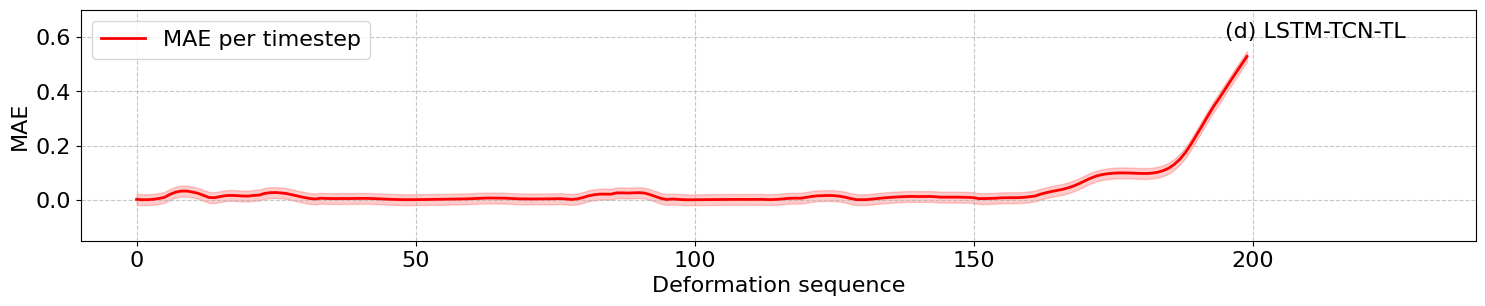

MAE per timestep plot saved and displayed: ./lstmtcn_tl_fig/mae_per_timestep.png


In [10]:
from scipy.signal import savgol_filter
from matplotlib.ticker import MultipleLocator

# 计算每个时间步的 MAE
mae_per_timestep = np.abs(new_output - new_predictions)

# 采样数据以减少密度（例如，每隔250个点取一个）
sampling_rate = 850
mae_sampled = mae_per_timestep[::sampling_rate]

# 确保 window_length 小于或等于数据长度，并且是奇数
window_length = min(11, len(mae_sampled))
if window_length % 2 == 0:
    window_length -= 1

# 如果 window_length 仍然大于数据长度，调整为数据长度的最大奇数
if window_length < 3:
    window_length = 3

# 平滑曲线（使用 Savitzky-Golay 滤波器）
polyorder = 2  # 确保 polyorder 小于 window_length
mae_smoothed = savgol_filter(mae_sampled, window_length, polyorder)

# 绘制 MAE 随时间变化的图
plt.figure(figsize=(18, 3))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(mae_smoothed, label='MAE per timestep', color='red', linewidth=2)

# 添加跟随曲线变化的窄色条
offset = 0.02  # 设置窄色条的宽度
plt.fill_between(range(len(mae_smoothed)), mae_smoothed - offset, mae_smoothed + offset, color='red', alpha=0.2)

# 设置图例位置为左上角
plt.legend(loc='upper left', fontsize=16)

# 在右上角添加文本 (c)
plt.text(0.95, 0.95, '(d) LSTM-TCN-TL', fontsize=16, ha='right', va='top', transform=plt.gca().transAxes)
# 设置Y轴范围
plt.ylim(min(mae_smoothed) - 0.1, max(mae_smoothed) + 0.1)
plt.xlabel('Deformation sequence', fontsize=16)
plt.ylabel('MAE', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-0.15, 0.7)
plt.xlim(-10, 240)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.2))

# 保存图像
mae_timestep_path = './lstmtcn_tl_fig/mae_per_timestep.png'
os.makedirs(os.path.dirname(mae_timestep_path), exist_ok=True)
plt.savefig(mae_timestep_path, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

# 关闭当前图形以释放内存
plt.close()

print(f"MAE per timestep plot saved and displayed: {mae_timestep_path}")


从磁盘加载 scaler_in / scaler_out
复用内存中的 TL 模型
[LSTM-TCN-TL] 建议范围 => vmin=6.57471e-06, vmax=28.4838
误差等高线图已保存为: lstmtcn_tl_fig/lstm_tcn_tl_error_contour_log_scale_formatted.png


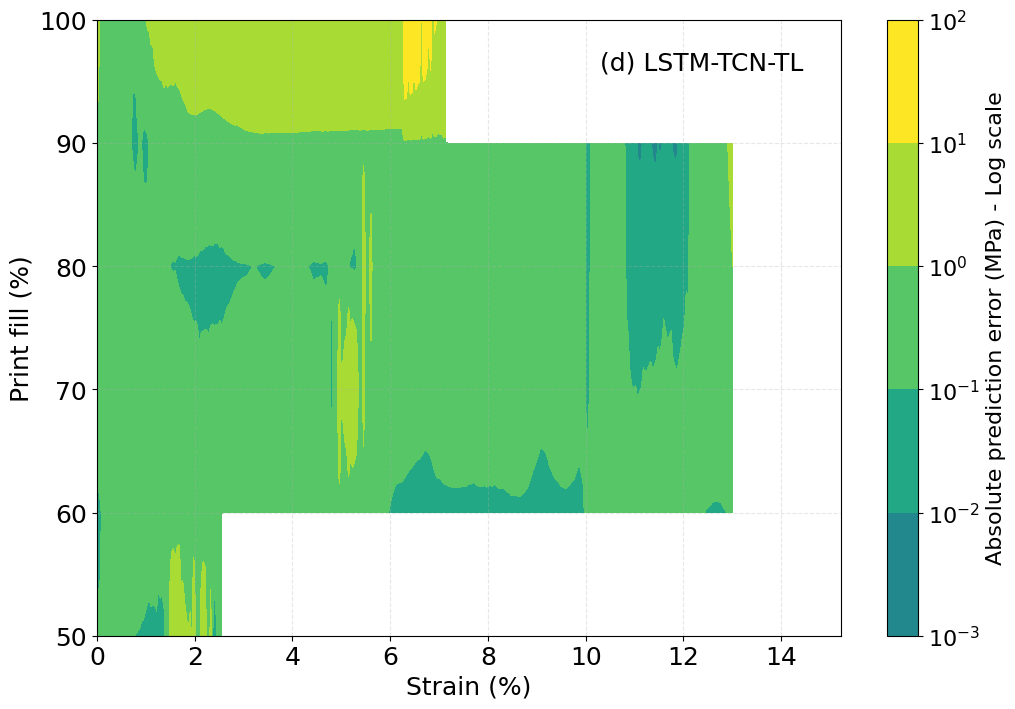

In [31]:
# 四图统一色条范围（LogNorm 要求 vmin > 0）
GLOBAL_VMIN = 1.13126e-06
GLOBAL_VMAX = 28.4838

# ===== 误差等高线（LSTM-TCN-TL）—— 两步线性插值 + LogNorm + 100级 contourf（无黑线与数值） =====
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import matplotlib.colors as mcolors
from tensorflow.keras.models import load_model
import joblib

# 1) 读取评估数据并预测（复用 scaler_in / scaler_out 与 TL 模型）
EVALUATION_DATA_PATH = 'Fill-1.csv'
df_eval = pd.read_csv(EVALUATION_DATA_PATH).drop_duplicates()

x_eval = df_eval.iloc[:, :2].values
y_eval = df_eval.iloc[:, 2].values.reshape(-1, 1)

# 尝试复用已加载的 scaler；若无，则从磁盘加载
try:
    _ = scaler_in.mean_
    _ = scaler_out.mean_
    print('复用内存中的 scaler_in / scaler_out')
except Exception:
    print('从磁盘加载 scaler_in / scaler_out')
    scaler_in = joblib.load('scalers/scaler_in.pkl')
    scaler_out = joblib.load('scalers/scaler_out.pkl')

x_eval_scaled = scaler_in.transform(x_eval)

# 序列长度（该模型代码中使用 timesteps=1）
sequence_length = 1

def create_sequences(data: np.ndarray, seq_length: int) -> np.ndarray:
    seqs = []
    for i in range(len(data) - seq_length + 1):
        seqs.append(data[i:i + seq_length])
    return np.array(seqs)

x_eval_seq = create_sequences(x_eval_scaled, sequence_length)

# 尝试复用内存中的模型；若无则从磁盘加载
try:
    _ = model.predict  # noqa
    print('复用内存中的 TL 模型')
except Exception:
    print('从磁盘加载 TL 模型')
    model = load_model('TCNmodel/lstm_tcn_tl_model_finetuned.h5')

# 预测并反归一化
y_pred_scaled = model.predict(x_eval_seq, verbose=0)
# y_pred_scaled 形状可能为 (N, 1) 或 (N, 1, 1)；统一成二维
if y_pred_scaled.ndim == 3:
    y_pred_scaled = y_pred_scaled.reshape(y_pred_scaled.shape[0], -1)

y_pred = scaler_out.inverse_transform(y_pred_scaled).flatten()

# 对齐真值与输入特征（序列预测对应最后一步）
y_true_aligned = y_eval[sequence_length - 1:].flatten()
angle_original = x_eval[sequence_length - 1:, 0].astype(float)
strain_original = x_eval[sequence_length - 1:, 1].astype(float)

absolute_error = np.abs(y_pred - y_true_aligned)

# 2) 构造 df_plot 并执行“两步一维线性插值”（沿应变→沿参数）
df_plot = pd.DataFrame({
    'Strain': strain_original,
    'Angle': angle_original,
    'Error': absolute_error.astype(float)
})

out_dir = os.path.join('error_points')
os.makedirs(out_dir, exist_ok=True)
df_plot.to_csv(os.path.join(out_dir, 'lstm_tcn_tl_points.csv'), index=False)

# 分组（按参数取整）
df_plot['Angle_Group'] = df_plot['Angle'].round(0)
unique_angles = sorted(df_plot['Angle_Group'].dropna().unique())

# 统一网格
grid_resolution = 400
strain_common = np.linspace(df_plot['Strain'].min(), df_plot['Strain'].max(), grid_resolution)
angle_grid_dense = np.linspace(df_plot['Angle'].min(), df_plot['Angle'].max(), grid_resolution)

# 第一步：每个角度组内沿应变插值
aligned_errors = {}
for ang in unique_angles:
    group = df_plot[df_plot['Angle_Group'] == ang].sort_values('Strain')
    if len(group) > 1:
        f_strain = interp1d(group['Strain'], group['Error'], bounds_error=False, fill_value=np.nan)
        aligned_errors[ang] = f_strain(strain_common)

# 第二步：对每个应变点沿参数轴插值
final_grid_error = np.full((len(angle_grid_dense), len(strain_common)), np.nan)
for i in range(len(strain_common)):
    current_errors = []
    valid_angles = []
    for ang in unique_angles:
        if ang in aligned_errors:
            current_errors.append(aligned_errors[ang][i])
            valid_angles.append(ang)
    if len(valid_angles) > 1:
        current_errors = np.array(current_errors, dtype=float)
        valid_angles = np.array(valid_angles, dtype=float)
        mask = ~np.isnan(current_errors)
        if np.sum(mask) > 1:
            f_angle = interp1d(valid_angles[mask], current_errors[mask], bounds_error=False, fill_value=np.nan)
            final_grid_error[:, i] = f_angle(angle_grid_dense)

# 3) 绘制：100级 contourf + LogNorm（不叠加黑线与数值）
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 8))

target_strain, target_angle = np.meshgrid(strain_common, angle_grid_dense)
final_grid_error_masked = np.ma.masked_invalid(final_grid_error)

# 动态 LogNorm：最小正误差到最大误差
min_error_for_log = df_plot['Error'][df_plot['Error'] > 0].min()
final_grid_error_masked = np.ma.masked_less_equal(final_grid_error, 0)
norm = mcolors.LogNorm(vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX)
contour = ax.contourf(target_strain, target_angle, final_grid_error_masked, levels=100, cmap='viridis', norm=norm)
print(f"[LSTM-TCN-TL] 建议范围 => vmin={min_error_for_log:.6g}, vmax={df_plot['Error'].max():.6g}")
# 颜色条与字体
cbar = fig.colorbar(contour)
cbar.set_label('Absolute prediction error (MPa) - Log scale', fontsize=16)
cbar.ax.tick_params(labelsize=16)

# 轴与网格
ax.set_xlabel('Strain (%)', fontsize=18)
ax.set_ylabel('Print fill (%)', fontsize=18)
ax.grid(True, linestyle='--', alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=18)

# 角标
ax.text(0.95, 0.95, '(d) LSTM-TCN-TL', transform=ax.transAxes, fontsize=18, ha='right', va='top')

# 保存
out_dir = os.path.join('lstmtcn_tl_fig')
os.makedirs(out_dir, exist_ok=True)
output_filename = os.path.join(out_dir, 'lstm_tcn_tl_error_contour_log_scale_formatted.png')
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"误差等高线图已保存为: {output_filename}")
plt.show()


In [ ]:
# 计算 60-p.csv 的 MAE / RMSE / R²（全量与 Strain≤5）并保存
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import load_model
import joblib

# 输出目录
out_dir = os.path.join('lstmtcn_tl_fig', 'prediction')
os.makedirs(out_dir, exist_ok=True)

# 加载 scaler（MinMaxScaler，与本笔记本一致）
try:
    _ = scaler_in.min_
    _ = scaler_out.min_
except Exception:
    scaler_in = joblib.load('scalers/scaler_in.pkl')
    scaler_out = joblib.load('scalers/scaler_out.pkl')

# 读取未见测试集
df_test = pd.read_csv('60-p.csv')
# 特征与目标（列顺序：[Angle, Strain, Stress]）
x_new = df_test.iloc[:, :2].values
strain = df_test.iloc[:, 1].values
stress_true = df_test.iloc[:, 2].values.reshape(-1, 1)

# 归一化 + 构造序列（timesteps=1）
x_new_scaled = scaler_in.transform(x_new)

def create_sequences(data, seq_len):
    seqs = []
    for i in range(len(data) - seq_len + 1):
        seqs.append(data[i:i + seq_len])
    return np.array(seqs)

sequence_length = 1
x_new_seq = create_sequences(x_new_scaled, sequence_length)

# 加载迁移学习后的模型
model_path = 'TCNmodel/lstm_tcn_tl_model_finetuned.h5'
model = load_model(model_path)

# 预测
y_pred_scaled = model.predict(x_new_seq, verbose=0)
# (N, 1, 1) 或 (N, 1) 统一成 (N, 1)
if y_pred_scaled.ndim == 3:
    y_pred_scaled = y_pred_scaled.reshape(-1, 1)

# 反归一化
y_pred = scaler_out.inverse_transform(y_pred_scaled).flatten()

# 对齐长度并扁平化（seq_len=1 时通常等长，这里稳妥处理）
min_len = min(len(stress_true), len(y_pred))
true_all = stress_true[:min_len].flatten()
pred_all = y_pred[:min_len].flatten()
strain_all = strain[:min_len]

# 全量指标
mse_all = mean_squared_error(true_all, pred_all)
rmse_all = np.sqrt(mse_all)
mae_all = mean_absolute_error(true_all, pred_all)
r2_all = r2_score(true_all, pred_all)

# 阈值内（与图一致）：Strain ≤ 5
mask = strain_all <= 5
true_thr = true_all[mask]
pred_thr = pred_all[mask]

mse_thr = mean_squared_error(true_thr, pred_thr) if len(true_thr) > 0 else np.nan
rmse_thr = np.sqrt(mse_thr) if np.isfinite(mse_thr) else np.nan
mae_thr = mean_absolute_error(true_thr, pred_thr) if len(true_thr) > 0 else np.nan
r2_thr = r2_score(true_thr, pred_thr) if len(true_thr) > 1 else np.nan

# 打印结果
print('=== 60-p.csv metrics (LSTM-TCN-TL) ===')
print(f'All samples   -> MAE={mae_all:.4f}, RMSE={rmse_all:.4f}, R²={r2_all:.4f}')
if np.isfinite(mae_thr):
    print(f'Strain≤5     -> MAE={mae_thr:.4f}, RMSE={rmse_thr:.4f}, R²={r2_thr:.4f}')
else:
    print('Strain≤5     -> 无有效样本')

# 保存 CSV
metrics_df = pd.DataFrame([
    {'scope': 'all',        'MAE': mae_all, 'RMSE': rmse_all, 'R2': r2_all},
    {'scope': 'strain<=5',  'MAE': mae_thr, 'RMSE': rmse_thr, 'R2': r2_thr},
])
metrics_path = os.path.join(out_dir, '60-p_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f'Metrics saved to: {metrics_path}')


In [12]:
# 导出 LSTM-TCN-TL 残差CSV（pred-true），默认仅 Strain≤5
import os, numpy as np, pandas as pd, joblib
from tensorflow.keras.models import load_model

STRAIN_MAX = 5
SEQLEN = 1

# MinMaxScaler（该笔记本用 MinMax）
try:
    _ = scaler_in.min_; _ = scaler_out.min_
except Exception:
    scaler_in  = joblib.load('scalers/scaler_in.pkl')
    scaler_out = joblib.load('scalers/scaler_out.pkl')

model = load_model('TCNmodel/lstm_tcn_tl_model_finetuned.h5')

df = pd.read_csv('60-p.csv')
x_new = df.iloc[:, :2].values
strain = df.iloc[:, 1].values
y_true = df.iloc[:, 2].values

def make_seq(a, L): return np.array([a[i:i+L] for i in range(len(a)-L+1)])
x_scaled = scaler_in.transform(x_new)
x_seq = make_seq(x_scaled, SEQLEN)

y_pred_scaled = model.predict(x_seq, verbose=0)
if y_pred_scaled.ndim == 3:
    y_pred_scaled = y_pred_scaled.reshape(-1, 1)
y_pred = scaler_out.inverse_transform(y_pred_scaled).flatten()

n = min(len(strain), len(y_true), len(y_pred))
strain = strain[:n]
residual = y_pred[:n] - y_true[:n]

if STRAIN_MAX is not None:
    mask = strain <= STRAIN_MAX
    strain, residual = strain[mask], residual[mask]

out_dir = 'lstmtcn_tl_fig/prediction'; os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'residuals_LSTMTCN_TL.csv')
pd.DataFrame({'strain': strain, 'residual': residual}).to_csv(out_path, index=False)
print('saved:', out_path)

saved: lstmtcn_tl_fig/prediction/residuals_LSTMTCN_TL.csv
